# ClusWisard — Detecção de Anomalias em IoT (TON_IoT Dataset)

Este notebook implementa um modelo **ClusWisard** (Clustering WiSARD) para detecção de anomalias no dataset TON_IoT (UNSW Canberra Cyber), seguindo o roteiro definido em `PLANO.md` e a análise exploratória de `01_eda_telemetry.ipynb`.

## Redes Neurais sem Pesos (Weightless Neural Networks)

WiSARD (Wilkes, Stonham and Aleksander's Recognition Device) é uma rede neural **sem pesos** baseada em RAMs (Random Access Memory). Em vez de pesos sinápticos, utiliza **endereçamento binário** de posições de memória:

- **Entrada**: vetor binário `x ∈ {0,1}^n`
- **RAM**: cada neurônio é uma RAM indexada por `addressSize` bits
- **Treinamento**: incrementa contadores na posição endereçada
- **Inferência**: soma votos das RAMs por classe; vencedor = classe com mais votos

### ClusWisard
Extensão que permite **múltiplos discriminadores por classe** (clusters). Quando uma entrada não satisfaz nenhum cluster existente (score < threshold), um novo cluster é criado — permitindo modelar distribuições multimodais dentro de cada classe.

## Tarefas
- **Binária**: normal (0) vs. ataque (1)
- **Multi-classe**: tipo específico de ataque (ddos, injection, password, etc.)

## Métricas (conforme PLANO.md)
- Acurácia, Precisão, Recall, F1 (macro e weighted)
- AUC-ROC (OvR macro para multi-classe)
- Matriz de confusão
- Memória do modelo (serializada)
- Tempo de treino e latência de inferência

## 0. Instalação

Execute a célula abaixo se estiver no Google Colab ou em um ambiente sem as dependências instaladas.

In [19]:
# Instale os pacotes necessários (descomente conforme necessário)

# Versão base do wisardpkg (PyPI)
# !pip install wisardpkg pandas numpy scikit-learn matplotlib seaborn

# Versão fork com termômetros ajustados, BloomWisard e modelos PyTorch:
# !pip install git+https://github.com/muanlartins/wisardpkg@muanlartins --no-build-isolation

# Se estiver usando o código local (wisardpkg-master baixado):
# !cd /caminho/para/wisardpkg-master && pip install -e . --no-build-isolation

## 1. Imports e Configuração

In [20]:
import wisardpkg as wp
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize
import time
import json
import warnings
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f"wisardpkg version: {wp.__version__ if hasattr(wp, '__version__') else 'unknown'}")
print(f"Classes disponíveis: {[c for c in dir(wp) if not c.startswith('_')]}")

wisardpkg version: 2.0.0a7
Classes disponíveis: ['BestBleaching', 'BinBase', 'BinInput', 'Bleaching', 'BloomWisard', 'ClassificationBase', 'ClassificationModel', 'ClusRegressionWisard', 'ClusWisard', 'ColorMaskBinarization', 'DataSet', 'Discriminator', 'DistributiveThermometer', 'DynamicThermometer', 'ExponentialMean', 'ExponentialThermometer', 'GaussianThermometer', 'GeometricMean', 'HarmonicMean', 'HarmonicPowerMean', 'KernelCanvas', 'Local2DMapping', 'LogisticMean', 'MappingGenerator', 'Mean', 'MeanThresholding', 'Median', 'Model', 'PowerMean', 'RAMDataHandle', 'RandomMapping', 'RegressionModel', 'RegressionRAMDataHandle', 'RegressionWisard', 'SimpleMean', 'SimpleThermometer', 'StochasticThermometer', 'SupervisedThermometer', 'Synthesizer', 'Thresholding', 'Weighted', 'Wisard', 'config_sufix', 'dataset_sufix', 'ramdata_sufix']


In [21]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
DATA_PATH = Path(r'C:\Users\mayara\Documents\Estudo\Mestrado\Redes Neurais sem peso\datasets\Train_Test_IoT_dataset')
RESULTS_PATH = Path('results/cluswisard')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# ── Reprodutibilidade ──────────────────────────────────────────────────────────
SEED        = 0
TRAIN_RATIO = 0.70   # 70/30 conforme PLANO.md

# ── Datasets disponíveis ───────────────────────────────────────────────────────
DATASETS = {
    'Fridge'      : 'Train_Test_IoT_Fridge.csv',
    'GPS_Tracker' : 'Train_Test_IoT_GPS_Tracker.csv',
    'Motion_Light': 'Train_Test_IoT_Motion_Light.csv',
    'Garage_Door' : 'Train_Test_IoT_Garage_Door.csv',
    'Modbus'      : 'Train_Test_IoT_Modbus.csv',
    'Thermostat'  : 'Train_Test_IoT_Thermostat.csv',
    'Weather'     : 'Train_Test_IoT_Weather.csv',
}

# ── Grade de hiperparâmetros (PLANO.md) ────────────────────────────────────────
THERM_TYPES  = ['Simple', 'Distributive', 'Gaussian', 'Exponential']
THERM_SIZES  = [2, 4, 8, 16, 32, 64]   # potências de 2
ADDR_SIZES   = [4, 8, 12, 16, 20, 24, 28, 32]  # 4..32 passo 4

# ── Parâmetros fixos do ClusWisard ─────────────────────────────────────────────
MIN_SCORE           = 0.0   # score mínimo para classificar
THRESHOLD           = 1     # limiar para criar novo cluster
DISCRIMINATORS_LIMIT = 100    # 0 = ilimitado   // alterando para 100

TASKS = ['binary', 'multiclass']
print("Configuração carregada com sucesso.")

Configuração carregada com sucesso.


## 2. Definição das Features por Dataset

Baseado na análise exploratória (`01_eda_telemetry.ipynb`), cada dataset tem um perfil distinto de features:

| Dataset | Numéricas | Binárias Int | Binárias Cat | K-árias Cat |
|---------|-----------|--------------|--------------|-------------|
| Fridge | fridge_temperature | — | temp_condition | — |
| GPS_Tracker | latitude, longitude | — | — | — |
| Motion_Light | — | motion_status | light_status | — |
| Garage_Door | — | sphone_signal | door_state | — |
| Modbus | FC1, FC2, FC3, FC4 | — | — | — |
| Thermostat | current_temperature | thermostat_status | — | — |
| Weather | temperature, pressure, humidity | — | — | — |

**Colunas excluídas**: `date`, `time` (vazamento temporal conforme EDA)

In [22]:
# Definição explícita por dataset (colunas já em lower case após clean_df)
DATASET_FEATURES = {
    'Fridge': {
        'numeric'    : ['fridge_temperature'],
        'binary_int' : [],
        'binary_cat' : ['temp_condition'],   # 'high' / 'low'
        'kary_cat'   : [],
    },
    'GPS_Tracker': {
        'numeric'    : ['latitude', 'longitude'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Motion_Light': {
        'numeric'    : [],
        'binary_int' : ['motion_status'],
        'binary_cat' : ['light_status'],     # 'on' / 'off'
        'kary_cat'   : [],
    },
    'Garage_Door': {
        'numeric'    : [],
        'binary_int' : ['sphone_signal'],
        'binary_cat' : ['door_state'],       # 'open' / 'closed'
        'kary_cat'   : [],
    },
    'Modbus': {
        'numeric'    : ['fc1_read_input_register', 'fc2_read_discrete_value',
                        'fc3_read_holding_register', 'fc4_read_coil'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Thermostat': {
        'numeric'    : ['current_temperature'],
        'binary_int' : ['thermostat_status'],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Weather': {
        'numeric'    : ['temperature', 'pressure', 'humidity'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
}
print("Features definidas para todos os datasets.")

Features definidas para todos os datasets.


## 3. Pré-processamento

In [23]:
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza colunas e valores conforme 01_eda_telemetry.ipynb."""
    df = df.copy()
    # Normaliza nomes de colunas
    df.columns = [c.strip().lower() for c in df.columns]
    # Strip + lowercase em colunas texto
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower()
    # sphone_signal: '0','1','false','true' → Int64
    if 'sphone_signal' in df.columns:
        mapping = {'0': 0, '1': 1, 'false': 0, 'true': 1, 0: 0, 1: 1}
        df['sphone_signal'] = df['sphone_signal'].map(mapping).astype('Int64')
    # label como int
    if 'label' in df.columns:
        df['label'] = df['label'].astype(int)
    return df


def load_dataset(name: str, task: str = 'binary'):
    """Carrega e prepara um dataset TON_IoT.
    
    Returns:
        X: DataFrame de features
        y: Series de labels (strings)
    """
    path = DATA_PATH / DATASETS[name]
    df = pd.read_csv(path, encoding='utf-8-sig')
    df = clean_df(df)
    # Remove colunas com vazamento temporal
    drop_cols = [c for c in ['date', 'time'] if c in df.columns]
    df = df.drop(columns=drop_cols)
    X = df.drop(columns=['label', 'type'])
    y = df['label'].astype(str) if task == 'binary' else df['type']
    return X, y


# Verificação rápida
X_demo, y_demo = load_dataset('Fridge', 'binary')
print(f"Fridge — Shape: {X_demo.shape}")
print(f"Features: {list(X_demo.columns)}")
print(f"Distribuição de labels (binary):\n{y_demo.value_counts()}")

Fridge — Shape: (39944, 2)
Features: ['fridge_temperature', 'temp_condition']
Distribuição de labels (binary):
label
1    24944
0    15000
Name: count, dtype: int64


In [24]:
# Resumo dos datasets
print(f"{'Dataset':<15} {'Amostras':>10} {'Labels binário':>18} {'Tipos de ataque':>8}")
print('-' * 60)
for name in DATASETS:
    X, y_bin = load_dataset(name, 'binary')
    _, y_multi = load_dataset(name, 'multiclass')
    n_attacks = len(y_multi.unique()) - 1  # menos 'normal'
    dist = y_bin.value_counts()
    n0, n1 = dist.get('0', 0), dist.get('1', 0)
    print(f"{name:<15} {len(X):>10,} {f'{n0:,} / {n1:,}':>18} {n_attacks:>8}")

Dataset           Amostras     Labels binário Tipos de ataque
------------------------------------------------------------
Fridge              39,944    15,000 / 24,944        6
GPS_Tracker         38,960    15,000 / 23,960        7
Motion_Light        39,488    15,000 / 24,488        7
Garage_Door         39,587    15,000 / 24,587        7
Modbus              31,106    15,000 / 16,106        5
Thermostat          32,774    15,000 / 17,774        6
Weather             39,260    15,000 / 24,260        7


## 4. Pipeline de Binarização

A binarização converte features contínuas e categóricas em vetores binários `{0,1}^n` para entrada na rede WiSARD.

### Estratégia (conforme PLANO.md e EDA)
| Tipo de feature | Codificação | Bits |
|-----------------|-------------|------|
| Numérica | Termômetro (n bits) | `therm_size` por feature |
| Binária inteira (0/1) | Passagem direta | 1 bit |
| Binária categórica (2 valores) | 0/1 por ordem lexicográfica | 1 bit |
| K-ária categórica (k>2) | One-hot | k bits |

### Tipos de termômetro
- **Simple**: usa min/max do treino como limites uniformes
- **Distributive**: thresholds nos quantis equidistantes da distribuição empírica
- **Gaussian**: thresholds na distribuição gaussiana ajustada
- **Exponential**: thresholds na distribuição exponencial ajustada

In [25]:
def build_cat_encoders(X_train: pd.DataFrame, features: dict) -> dict:
    """Aprende mapeamento valor→índice para features categóricas a partir do treino."""
    encoders = {}
    for feat in features['binary_cat'] + features['kary_cat']:
        unique_vals = sorted(X_train[feat].dropna().unique())
        encoders[feat] = {v: i for i, v in enumerate(unique_vals)}
    return encoders


def build_thermometer(therm_type: str, therm_size: int, X_train_numeric: pd.DataFrame):
    """Ajusta e retorna um termômetro sobre as features numéricas de treino."""
    data_matrix = X_train_numeric.values.tolist()
    n_feat = len(X_train_numeric.columns)

    if therm_type == 'Simple':
        # DynamicThermometer permite min/max distintos por feature
        mins = X_train_numeric.min().tolist()
        maxs = X_train_numeric.max().tolist()
        # Garante que min != max para evitar divisão por zero
        for i in range(n_feat):
            if mins[i] == maxs[i]:
                maxs[i] = mins[i] + 1.0
        therm = wp.DynamicThermometer(
            thermometerSizes=[therm_size] * n_feat,
            minimum=mins,
            maximum=maxs
        )
    elif therm_type == 'Distributive':
        therm = wp.DistributiveThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    elif therm_type == 'Gaussian':
        therm = wp.GaussianThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    elif therm_type == 'Exponential':
        therm = wp.ExponentialThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    else:
        raise ValueError(f"Tipo de termômetro desconhecido: {therm_type}")

    return therm


def binarize_row(row: pd.Series, features: dict, therm, cat_encoders: dict) -> list:
    """Converte uma linha do DataFrame em lista binária plana."""
    bits = []

    # Features numéricas → termômetro
    if features['numeric']:
        numeric_vals = [float(row[f]) for f in features['numeric']]
        result = therm.transform(numeric_vals)
        bits.extend(result.list())

    # Features binárias inteiras (já são 0 ou 1)
    for feat in features['binary_int']:
        val = row[feat]
        bits.append(int(val) if not pd.isna(val) else 0)

    # Features binárias categóricas (2 valores únicos → 1 bit)
    for feat in features['binary_cat']:
        val = row[feat]
        bits.append(cat_encoders[feat].get(str(val).strip(), 0))

    # Features k-árias categóricas (k > 2 → one-hot com k bits)
    for feat in features['kary_cat']:
        val = row[feat]
        encoder = cat_encoders[feat]
        k = len(encoder)
        one_hot = [0] * k
        idx = encoder.get(str(val).strip())
        if idx is not None:
            one_hot[idx] = 1
        bits.extend(one_hot)

    return bits


def build_wisard_dataset(X: pd.DataFrame, y: pd.Series,
                         features: dict, therm, cat_encoders: dict) -> wp.DataSet:
    """Binariza todo o DataFrame e constrói um wisardpkg.DataSet."""
    ds = wp.DataSet()
    for idx in range(len(X)):
        row = X.iloc[idx]
        label = str(y.iloc[idx])
        bits = binarize_row(row, features, therm, cat_encoders)
        ds.add(bits, label)
    return ds


def count_input_bits(dataset_name: str, therm_size: int, X_train: pd.DataFrame) -> int:
    """Calcula o número total de bits de entrada após binarização."""
    feat = DATASET_FEATURES[dataset_name]
    numeric_bits = len(feat['numeric']) * therm_size
    binary_bits  = len(feat['binary_int']) + len(feat['binary_cat'])
    kary_bits    = sum(
        len(X_train[f].dropna().unique()) for f in feat['kary_cat']
    )
    return numeric_bits + binary_bits + kary_bits


print("Funções de binarização definidas.")

# Demonstração: tamanho de entrada por dataset e therm_size=8
X_fridge, _ = load_dataset('Fridge')
X_train_demo, _, _, _ = train_test_split(X_fridge, pd.Series([0]*len(X_fridge)),
                                          test_size=0.3, random_state=SEED)
print("\nBits de entrada por dataset (therm_size=8):")
for name in DATASETS:
    X, _ = load_dataset(name)
    X_tr, _, _, _ = train_test_split(X, pd.Series([0]*len(X)), test_size=0.3, random_state=SEED)
    bits = count_input_bits(name, 8, X_tr)
    print(f"  {name:<15}: {bits:>4} bits")

Funções de binarização definidas.

Bits de entrada por dataset (therm_size=8):
  Fridge         :    9 bits
  GPS_Tracker    :   16 bits
  Motion_Light   :    2 bits
  Garage_Door    :    2 bits
  Modbus         :   32 bits
  Thermostat     :    9 bits
  Weather        :   24 bits


## 5. Métricas de Avaliação

Conforme especificado no `PLANO.md`:
- **Desempenho**: Acurácia, Precisão/Recall/F1 (macro e weighted), AUC-ROC
- **Recursos**: Memória serializada (KB), Tempo de treino (s), Latência de inferência (µs/amostra)

In [26]:
def compute_metrics(y_true: list, y_pred: list,
                    all_scores: list, classes: set, task: str) -> dict:
    """Computa todas as métricas definidas no PLANO.md.
    
    Args:
        y_true: rótulos verdadeiros (lista de strings)
        y_pred: rótulos preditos (lista de strings)
        all_scores: lista de dicts {classe: score} por amostra
        classes: conjunto de classes únicas
        task: 'binary' ou 'multiclass'
    """
    metrics = {
        'accuracy'          : accuracy_score(y_true, y_pred),
        'precision_macro'   : precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro'      : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro'          : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

    # ── AUC-ROC ────────────────────────────────────────────────────────────────
    try:
        classes_sorted = sorted(list(classes))
        # Matriz de scores: shape (n_amostras, n_classes)
        score_matrix = np.array([
            [s.get(c, 0.0) if isinstance(s, dict) else 0.0 for c in classes_sorted]
            for s in all_scores
        ], dtype=float)
        # Normaliza para [0,1] como proxy de probabilidade
        row_sums = score_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        prob_matrix = score_matrix / row_sums

        if task == 'binary':
            # Score da classe positiva '1'
            pos_idx = classes_sorted.index('1') if '1' in classes_sorted else -1
            y_scores = prob_matrix[:, pos_idx] if pos_idx >= 0 else prob_matrix[:, 0]
            y_bin = [1 if l == '1' else 0 for l in y_true]
            metrics['auc_roc'] = float(roc_auc_score(y_bin, y_scores))
        else:
            # OvR macro para multi-classe
            y_true_bin = label_binarize(y_true, classes=classes_sorted)
            if y_true_bin.shape[1] == 1:
                metrics['auc_roc'] = None  # apenas 1 classe presente
            else:
                metrics['auc_roc'] = float(roc_auc_score(
                    y_true_bin, prob_matrix,
                    multi_class='ovr', average='macro'
                ))
    except Exception as e:
        metrics['auc_roc'] = None
        metrics['_auc_error'] = str(e)

    # ── Matriz de confusão ─────────────────────────────────────────────────────
    classes_sorted = sorted(list(classes))
    cm = confusion_matrix(y_true, y_pred, labels=classes_sorted)
    metrics['confusion_matrix'] = cm.tolist()
    metrics['confusion_matrix_labels'] = classes_sorted

    return metrics


def measure_memory(model) -> dict:
    """Mede o tamanho do modelo serializado (JSON)."""
    json_str = model.json()
    n_bytes = len(json_str.encode('utf-8'))
    return {
        'memory_bytes': n_bytes,
        'memory_kb'   : round(n_bytes / 1024, 2),
    }


print("Funções de métricas definidas.")

Funções de métricas definidas.


## 6. Modelo ClusWisard — Treinamento e Avaliação

### Como funciona o ClusWisard

1. **Inicialização**: cria um dicionário vazio de *clusters* por classe
2. **Treinamento** (para cada amostra rotulada):
   - Calcula o score em cada cluster existente da mesma classe
   - Se `max_score ≥ threshold`: atualiza o cluster com maior ativação
   - Se `max_score < threshold`: cria um novo cluster para essa amostra
3. **Classificação** (para cada amostra de teste):
   - Calcula score em todos os clusters de todas as classes
   - Retorna a classe cujo melhor cluster teve maior ativação
   - Se todos os scores < `minScore`: retorna classe desconhecida

In [27]:
def run_experiment(
    dataset_name: str,
    task: str,
    therm_type: str,
    therm_size: int,
    addr_size: int,
    min_score: float = MIN_SCORE,
    threshold: int = THRESHOLD,
    disc_limit: int = DISCRIMINATORS_LIMIT,
) -> dict | None:
    """Executa um experimento completo com ClusWisard.

    Returns:
        dict com todas as métricas e configurações, ou None se configuração inválida.
    """
    features = DATASET_FEATURES[dataset_name]
    has_numeric = len(features['numeric']) > 0

    # ── Carregar dados ─────────────────────────────────────────────────────────
    X, y = load_dataset(dataset_name, task)
    classes = set(y.unique())

    # ── Divisão treino/teste estratificada (70/30) ─────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1 - TRAIN_RATIO, random_state=SEED, stratify=y
    )

    # ── Ajustar termômetro (apenas nos dados de treino) ────────────────────────
    therm = None
    if has_numeric:
        therm = build_thermometer(therm_type, therm_size,
                                  X_train[features['numeric']])

    # ── Encoders categóricos (apenas do treino) ────────────────────────────────
    cat_encoders = build_cat_encoders(X_train, features)

    # ── Calcular total de bits ─────────────────────────────────────────────────
    total_bits = count_input_bits(dataset_name,
                                  therm_size if has_numeric else 0,
                                  X_train)
    if total_bits == 0 or addr_size > total_bits:
        return None  # configuração inválida

    # ── Binarizar conjuntos ────────────────────────────────────────────────────
    train_ds = build_wisard_dataset(X_train, y_train, features, therm, cat_encoders)
    test_ds  = build_wisard_dataset(X_test,  y_test,  features, therm, cat_encoders)

    # ── Criar e treinar ClusWisard ─────────────────────────────────────────────
    model = wp.ClusWisard(
        addr_size,   # addressSize: bits por RAM
        min_score,   # minScore: score mínimo para classificar
        threshold,   # threshold: limiar para criar novo cluster
        disc_limit   # discriminatorsLimit: 0 = ilimitado
    )

    t0 = time.perf_counter()
    model.train(train_ds)
    train_time_s = time.perf_counter() - t0

    # ── Classificar e medir latência ───────────────────────────────────────────
    t0 = time.perf_counter()
    predictions = model.classify(test_ds)
    infer_time_s = time.perf_counter() - t0
    infer_latency_us = infer_time_s / len(y_test) * 1e6

    # ── Scores para AUC ───────────────────────────────────────────────────────
    try:
        all_scores = model.getAllScores(test_ds)
    except Exception:
        try:
            all_scores = model.rank(test_ds)
        except Exception:
            all_scores = [{} for _ in range(len(y_test))]

    # ── Métricas ───────────────────────────────────────────────────────────────
    y_true = list(y_test.astype(str))
    y_pred = [str(p) for p in predictions]
    metrics = compute_metrics(y_true, y_pred, all_scores, classes, task)

    # ── Memória ────────────────────────────────────────────────────────────────
    memory = measure_memory(model)

    return {
        # Configuração
        'dataset'          : dataset_name,
        'task'             : task,
        'thermometer_type' : therm_type if has_numeric else 'N/A',
        'thermometer_size' : therm_size if has_numeric else 0,
        'address_size'     : addr_size,
        'total_input_bits' : total_bits,
        'min_score'        : min_score,
        'threshold'        : threshold,
        'discriminators_limit': disc_limit,
        'n_train'          : len(y_train),
        'n_test'           : len(y_test),
        # Desempenho
        'train_time_s'     : round(train_time_s, 5),
        'infer_latency_us' : round(infer_latency_us, 4),
        **memory,
        **metrics,
    }


print("Função run_experiment() definida.")

Função run_experiment() definida.


## 7. Experimento Demonstrativo (Único)

Valida o pipeline completo antes do grid search.

In [28]:
print("=" * 60)
print("Experimento demonstrativo: Fridge / binary / Distributive(8) / addr=8")
print("=" * 60)

demo_result = run_experiment(
    dataset_name='Fridge',
    task='binary',
    therm_type='Distributive',
    therm_size=8,
    addr_size=8,
)

if demo_result:
    print(f"\nBits de entrada : {demo_result['total_input_bits']}")
    print(f"Acurácia        : {demo_result['accuracy']:.4f}")
    print(f"F1 Macro        : {demo_result['f1_macro']:.4f}")
    print(f"F1 Weighted     : {demo_result['f1_weighted']:.4f}")
    print(f"AUC-ROC         : {demo_result.get('auc_roc')}")
    print(f"Tempo treino    : {demo_result['train_time_s']:.4f}s")
    print(f"Latência infer. : {demo_result['infer_latency_us']:.2f}µs/amostra")
    print(f"Memória         : {demo_result['memory_kb']:.2f}KB")
    print(f"\nMatriz de Confusão:")
    cm = np.array(demo_result['confusion_matrix'])
    labels = demo_result['confusion_matrix_labels']
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    print(df_cm)
else:
    print("Experimento inválido (addr_size > total_bits)")

Experimento demonstrativo: Fridge / binary / Distributive(8) / addr=8

Bits de entrada : 9
Acurácia        : 0.6245
F1 Macro        : 0.3844
F1 Weighted     : 0.4801
AUC-ROC         : None
Tempo treino    : 0.0338s
Latência infer. : 7.26µs/amostra
Memória         : 2.69KB

Matriz de Confusão:
   0     1
0  0  4500
1  0  7484


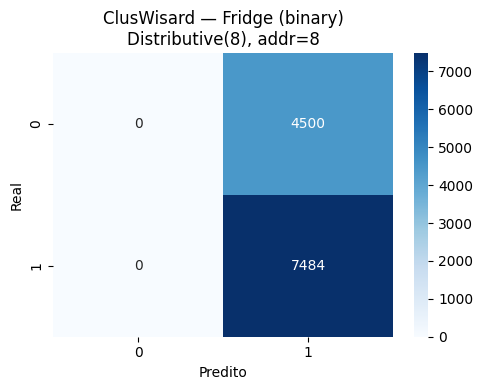

In [29]:
# Visualizar matriz de confusão do experimento demonstrativo
if demo_result:
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_arr = np.array(demo_result['confusion_matrix'])
    labels = demo_result['confusion_matrix_labels']
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title('ClusWisard — Fridge (binary)\nDistributive(8), addr=8')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'demo_confusion_matrix.png', dpi=150)
    plt.show()

## 8. Grid Search de Hiperparâmetros

Explorando as três dimensões ortogonais definidas no `PLANO.md`:
- **Tipo de termômetro**: Simple, Distributive, Gaussian, Exponential
- **Tamanho do termômetro**: 2, 4, 8, 16, 32, 64
- **Address size**: 4, 8, 12, 16, 20, 24, 28, 32

> **Nota**: O grid completo (~192 configs por dataset/task × 7 datasets × 2 tasks = ~2.688 experimentos) pode levar várias horas. Use o grid reduzido (`QUICK_MODE=True`) para validação rápida.

In [30]:
# ── Configurar modo de execução ────────────────────────────────────────────────
QUICK_MODE = True   # True = grid reduzido | False = grid completo (PLANO.md)

if QUICK_MODE:
    RUN_THERM_TYPES = ['Distributive', 'Gaussian']
    RUN_THERM_SIZES = [8, 16, 32]
    RUN_ADDR_SIZES  = [4, 8, 16]
    print("Modo RÁPIDO: 2 termômetros × 3 tamanhos × 3 addr_sizes =",
          f"{2*3*3} configs por dataset/task")
else:
    RUN_THERM_TYPES = THERM_TYPES
    RUN_THERM_SIZES = THERM_SIZES
    RUN_ADDR_SIZES  = ADDR_SIZES
    print("Modo COMPLETO: 4 termômetros × 6 tamanhos × 8 addr_sizes =",
          f"{4*6*8} configs por dataset/task")

Modo RÁPIDO: 2 termômetros × 3 tamanhos × 3 addr_sizes = 18 configs por dataset/task


In [31]:
def run_grid_search(
    dataset_name: str,
    task: str,
    therm_types=None,
    therm_sizes=None,
    addr_sizes=None,
    verbose: bool = True,
) -> list:
    """Executa a busca em grade para um par dataset/task."""
    if therm_types is None: therm_types = RUN_THERM_TYPES
    if therm_sizes is None: therm_sizes = RUN_THERM_SIZES
    if addr_sizes  is None: addr_sizes  = RUN_ADDR_SIZES

    features = DATASET_FEATURES[dataset_name]
    has_numeric = len(features['numeric']) > 0

    # Para datasets sem features numéricas, tipo/tamanho de termômetro não importa
    if not has_numeric:
        effective_therm_types = ['Simple']
        effective_therm_sizes = [1]
    else:
        effective_therm_types = therm_types
        effective_therm_sizes = therm_sizes

    results = []
    configs = list(product(effective_therm_types, effective_therm_sizes, addr_sizes))
    total = len(configs)

    for i, (therm_type, therm_size, addr_size) in enumerate(configs, 1):
        if verbose:
            print(f"  [{i:3}/{total}] therm={therm_type:<15}({therm_size:>2}), "
                  f"addr={addr_size:>2}", end=' → ')
        try:
            result = run_experiment(dataset_name, task, therm_type, therm_size, addr_size)
            if result is None:
                if verbose: print("SKIP")
                continue
            results.append(result)
            if verbose:
                auc = f"{result['auc_roc']:.4f}" if result.get('auc_roc') else 'N/A'
                print(f"acc={result['accuracy']:.4f}  "
                      f"f1={result['f1_macro']:.4f}  auc={auc}")
        except Exception as e:
            if verbose: print(f"ERRO: {e}")

    return results


def save_results(results: list, dataset_name: str, task: str):
    """Salva resultados no formato JSON padronizado (PLANO.md)."""
    path = RESULTS_PATH / f"{dataset_name}__{task}.json"
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, default=str)
    print(f"  ✓ Salvo: {path} ({len(results)} configs)")


print("Funções de grid search definidas.")

Funções de grid search definidas.


In [32]:
# ── Executar grid search para todos os datasets e tarefas ──────────────────────
all_results = {}

for dataset_name in DATASETS.keys():
    for task in TASKS:
        key = f"{dataset_name}__{task}"
        print(f"\n{'='*60}")
        print(f" Dataset: {dataset_name}  |  Tarefa: {task}")
        print('='*60)

        results = run_grid_search(dataset_name, task, verbose=True)
        all_results[key] = results
        save_results(results, dataset_name, task)

print("\n" + "="*60)
print("Grid search concluído!")
total_configs = sum(len(v) for v in all_results.values())
print(f"Total de configurações válidas: {total_configs}")


 Dataset: Fridge  |  Tarefa: binary
  [  1/18] therm=Distributive   ( 8), addr= 4 → acc=0.6245  f1=0.3844  auc=N/A
  [  2/18] therm=Distributive   ( 8), addr= 8 → acc=0.6245  f1=0.3844  auc=N/A
  [  3/18] therm=Distributive   ( 8), addr=16 → SKIP
  [  4/18] therm=Distributive   (16), addr= 4 → acc=0.6245  f1=0.3844  auc=N/A
  [  5/18] therm=Distributive   (16), addr= 8 → acc=0.6245  f1=0.3844  auc=N/A
  [  6/18] therm=Distributive   (16), addr=16 → acc=0.6245  f1=0.3844  auc=N/A
  [  7/18] therm=Distributive   (32), addr= 4 → acc=0.6245  f1=0.3844  auc=N/A
  [  8/18] therm=Distributive   (32), addr= 8 → acc=0.6245  f1=0.3844  auc=N/A
  [  9/18] therm=Distributive   (32), addr=16 → acc=0.6245  f1=0.3844  auc=N/A
  [ 10/18] therm=Gaussian       ( 8), addr= 4 → acc=0.6245  f1=0.3844  auc=N/A
  [ 11/18] therm=Gaussian       ( 8), addr= 8 → acc=0.6245  f1=0.3844  auc=N/A
  [ 12/18] therm=Gaussian       ( 8), addr=16 → SKIP
  [ 13/18] therm=Gaussian       (16), addr= 4 → acc=0.6245  f1=0.38

## 9. Análise dos Resultados

In [33]:
# Consolidar em DataFrame
rows = []
for results in all_results.values():
    rows.extend(results)
df_all = pd.DataFrame(rows)

print(f"Total de experimentos: {len(df_all)}")
print(f"Colunas: {list(df_all.columns)}")
df_all.head(3)

Total de experimentos: 172
Colunas: ['dataset', 'task', 'thermometer_type', 'thermometer_size', 'address_size', 'total_input_bits', 'min_score', 'threshold', 'discriminators_limit', 'n_train', 'n_test', 'train_time_s', 'infer_latency_us', 'memory_bytes', 'memory_kb', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'auc_roc', '_auc_error', 'confusion_matrix', 'confusion_matrix_labels']


,dataset,task,thermometer_type,thermometer_size,address_size,total_input_bits,min_score,threshold,discriminators_limit,n_train,...,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_roc,_auc_error,confusion_matrix,confusion_matrix_labels
0,Fridge,binary,Distributive,8,4,9,0.0,1,100,27960,...,0.31225,0.5,0.384426,0.389999,0.624499,0.480147,None,float() argument must be a string or a real nu...,"[[0, 4500], [0, 7484]]","[0, 1]"
1,Fridge,binary,Distributive,8,8,9,0.0,1,100,27960,...,0.31225,0.5,0.384426,0.389999,0.624499,0.480147,None,float() argument must be a string or a real nu...,"[[0, 4500], [0, 7484]]","[0, 1]"
2,Fridge,binary,Distributive,16,4,17,0.0,1,100,27960,...,0.31225,0.5,0.384426,0.389999,0.624499,0.480147,None,float() argument must be a string or a real nu...,"[[0, 4500], [0, 7484]]","[0, 1]"


In [34]:
# Melhores configurações por dataset/task (por F1 Macro)
display_cols = [
    'dataset', 'task', 'thermometer_type', 'thermometer_size', 'address_size',
    'accuracy', 'f1_macro', 'f1_weighted', 'auc_roc',
    'train_time_s', 'infer_latency_us', 'memory_kb'
]

best = (
    df_all[display_cols]
    .sort_values('f1_macro', ascending=False)
    .groupby(['dataset', 'task'])
    .first()
    .reset_index()
)

print("=" * 80)
print("Melhor configuração por Dataset/Task (F1 Macro)")
print("=" * 80)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(best.to_string(index=False))

Melhor configuração por Dataset/Task (F1 Macro)
    dataset       task thermometer_type  thermometer_size  address_size  accuracy  f1_macro  f1_weighted auc_roc  train_time_s  infer_latency_us  memory_kb
     Fridge     binary     Distributive                 8             8    0.6245    0.3844       0.4801    None        0.0792           19.8495     2.6900
     Fridge multiclass         Gaussian                32            16    0.3755    0.0780       0.2050    None        0.1994          594.2650    53.7200
GPS_Tracker     binary     Distributive                32             8    0.8794    0.8688       0.8773    None        0.9873          557.9548    72.0500
GPS_Tracker multiclass     Distributive                32            16    0.5808    0.3772       0.5678    None        0.6331         1744.5013   127.9900
     Modbus     binary     Distributive                32            16    0.6983    0.6981       0.6984    None        1.6508          294.8614   458.8800
     Modbus mult

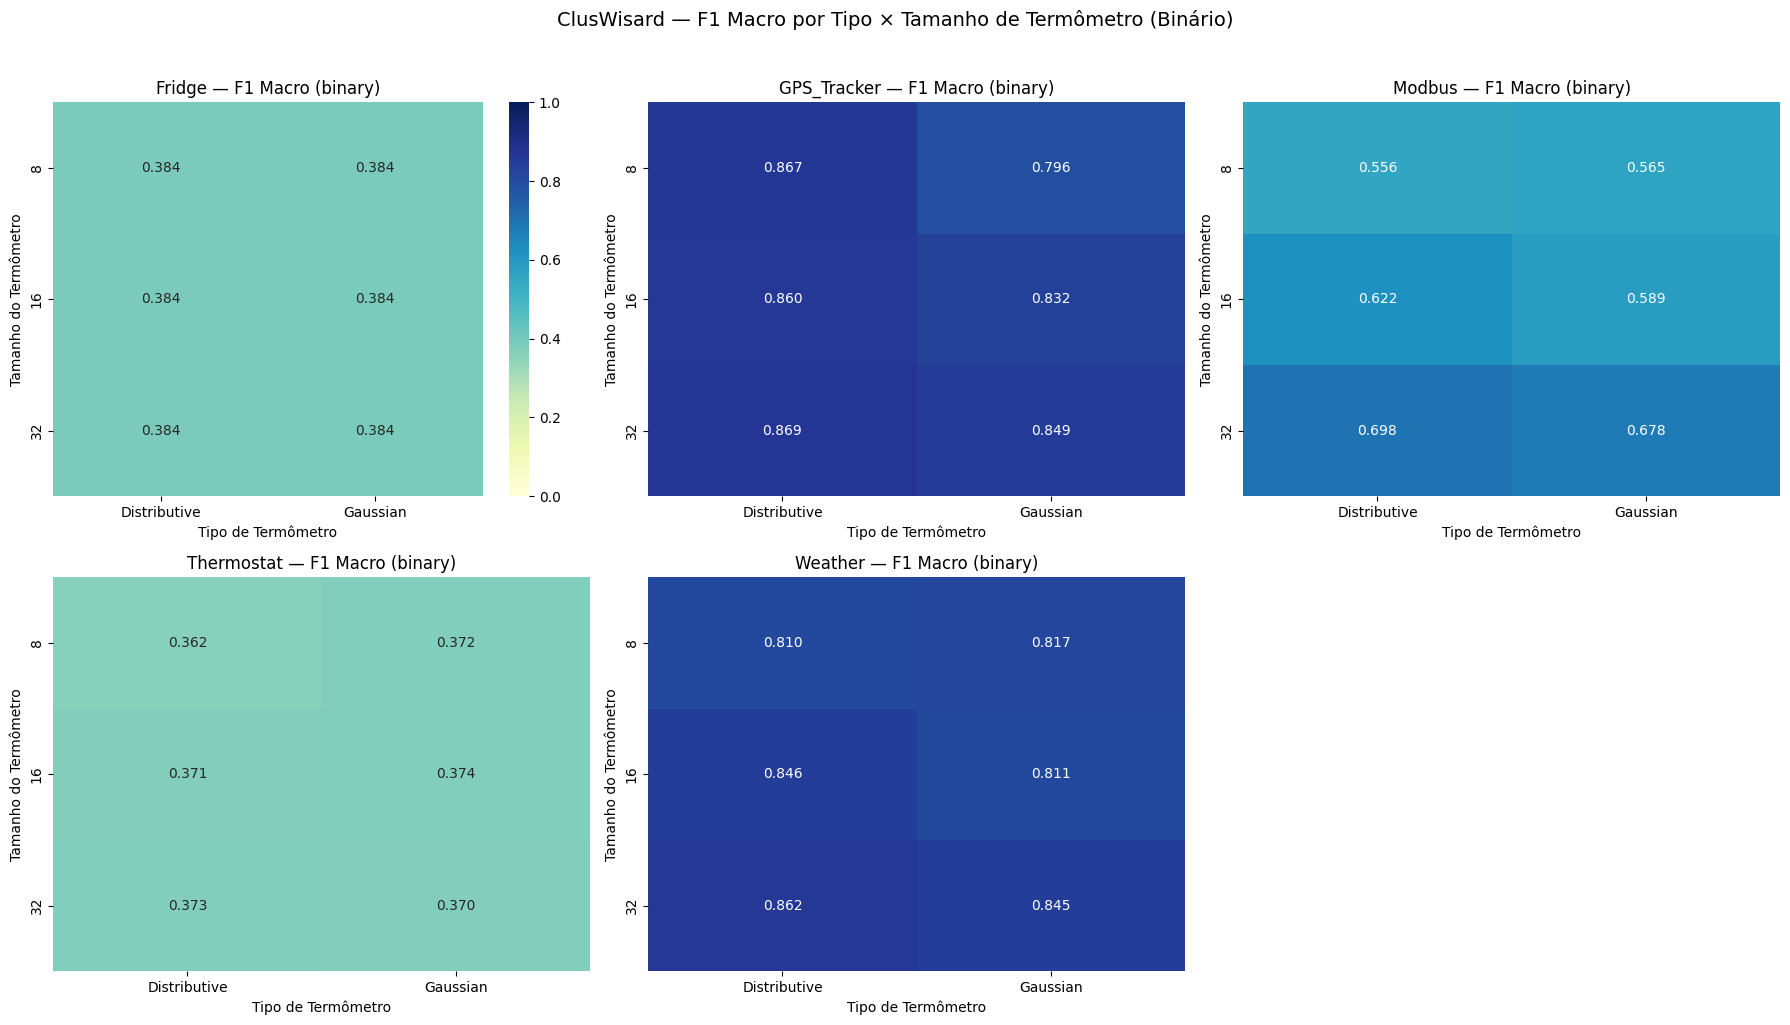

In [35]:
# ── Heatmap: F1 Macro por termômetro e addr_size (tarefa binária) ──────────────
df_binary = df_all[df_all['task'] == 'binary'].copy()

datasets_with_numeric = [n for n, f in DATASET_FEATURES.items() if len(f['numeric']) > 0]
n_plot = len(datasets_with_numeric)
fig, axes = plt.subplots(2, (n_plot + 1) // 2, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(datasets_with_numeric):
    sub = df_binary[df_binary['dataset'] == name]
    if sub.empty:
        continue
    pivot = sub.pivot_table(
        values='f1_macro',
        index='thermometer_size',
        columns='thermometer_type',
        aggfunc='max'
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=axes[i], cbar=i == 0)
    axes[i].set_title(f'{name} — F1 Macro (binary)')
    axes[i].set_xlabel('Tipo de Termômetro')
    axes[i].set_ylabel('Tamanho do Termômetro')

# Ocultar eixos extras
for j in range(len(datasets_with_numeric), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ClusWisard — F1 Macro por Tipo × Tamanho de Termômetro (Binário)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'heatmap_f1_therm_binary.png', dpi=150, bbox_inches='tight')
plt.show()

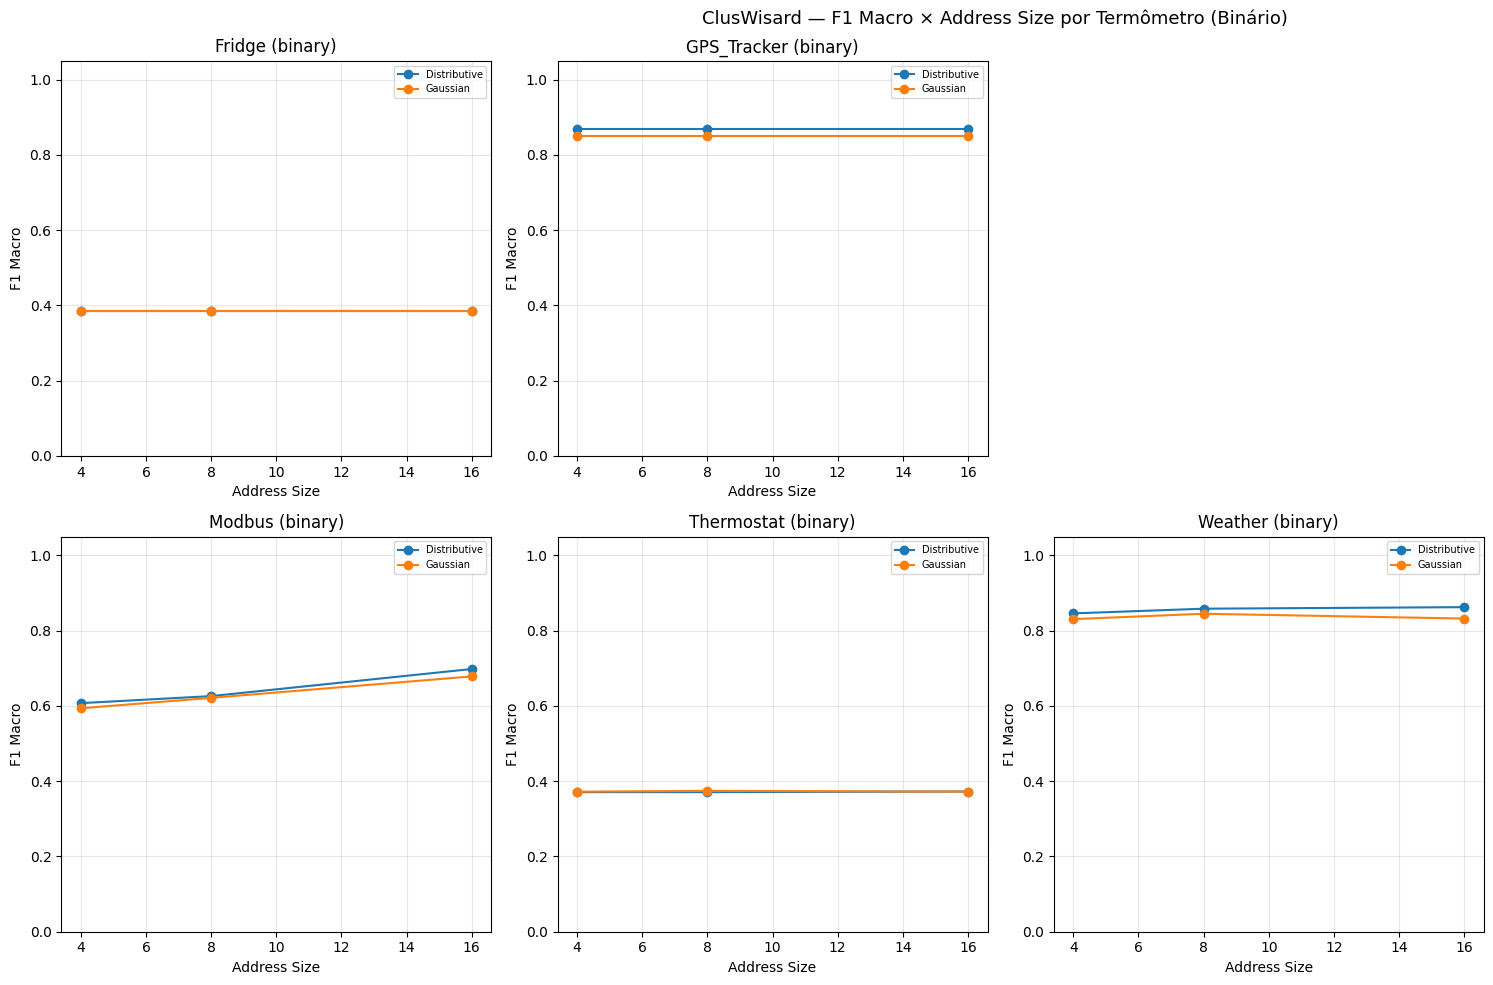

In [36]:
# ── F1 Macro × Address Size por dataset (tarefa binária) ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, name in enumerate(list(DATASETS.keys())):
    sub = df_binary[df_binary['dataset'] == name]
    if sub.empty:
        axes[i].set_visible(False)
        continue

    grp = sub.groupby(['address_size', 'thermometer_type'])['f1_macro'].max().reset_index()
    for therm_type, gdf in grp.groupby('thermometer_type'):
        axes[i].plot(gdf['address_size'], gdf['f1_macro'], marker='o', label=therm_type)
    axes[i].set_title(f'{name} (binary)')
    axes[i].set_xlabel('Address Size')
    axes[i].set_ylabel('F1 Macro')
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

for j in range(len(DATASETS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ClusWisard — F1 Macro × Address Size por Termômetro (Binário)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'f1_vs_addr_size_binary.png', dpi=150)
plt.show()

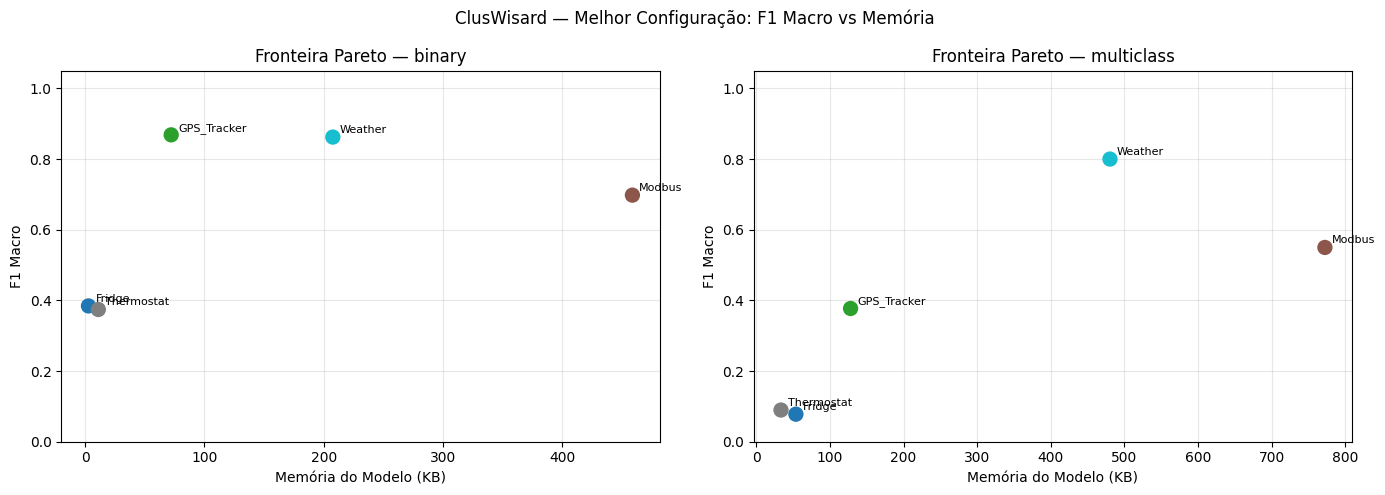

In [37]:
# ── Pareto: F1 Macro vs Memória (melhor config por dataset/task) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    best_task = best[best['task'] == task]
    sc = ax.scatter(
        best_task['memory_kb'], best_task['f1_macro'],
        c=range(len(best_task)), cmap='tab10', s=100, zorder=5
    )
    for _, row in best_task.iterrows():
        ax.annotate(row['dataset'], (row['memory_kb'], row['f1_macro']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.set_xlabel('Memória do Modelo (KB)')
    ax.set_ylabel('F1 Macro')
    ax.set_title(f'Fronteira Pareto — {task}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('ClusWisard — Melhor Configuração: F1 Macro vs Memória')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'pareto_f1_memory.png', dpi=150)
plt.show()

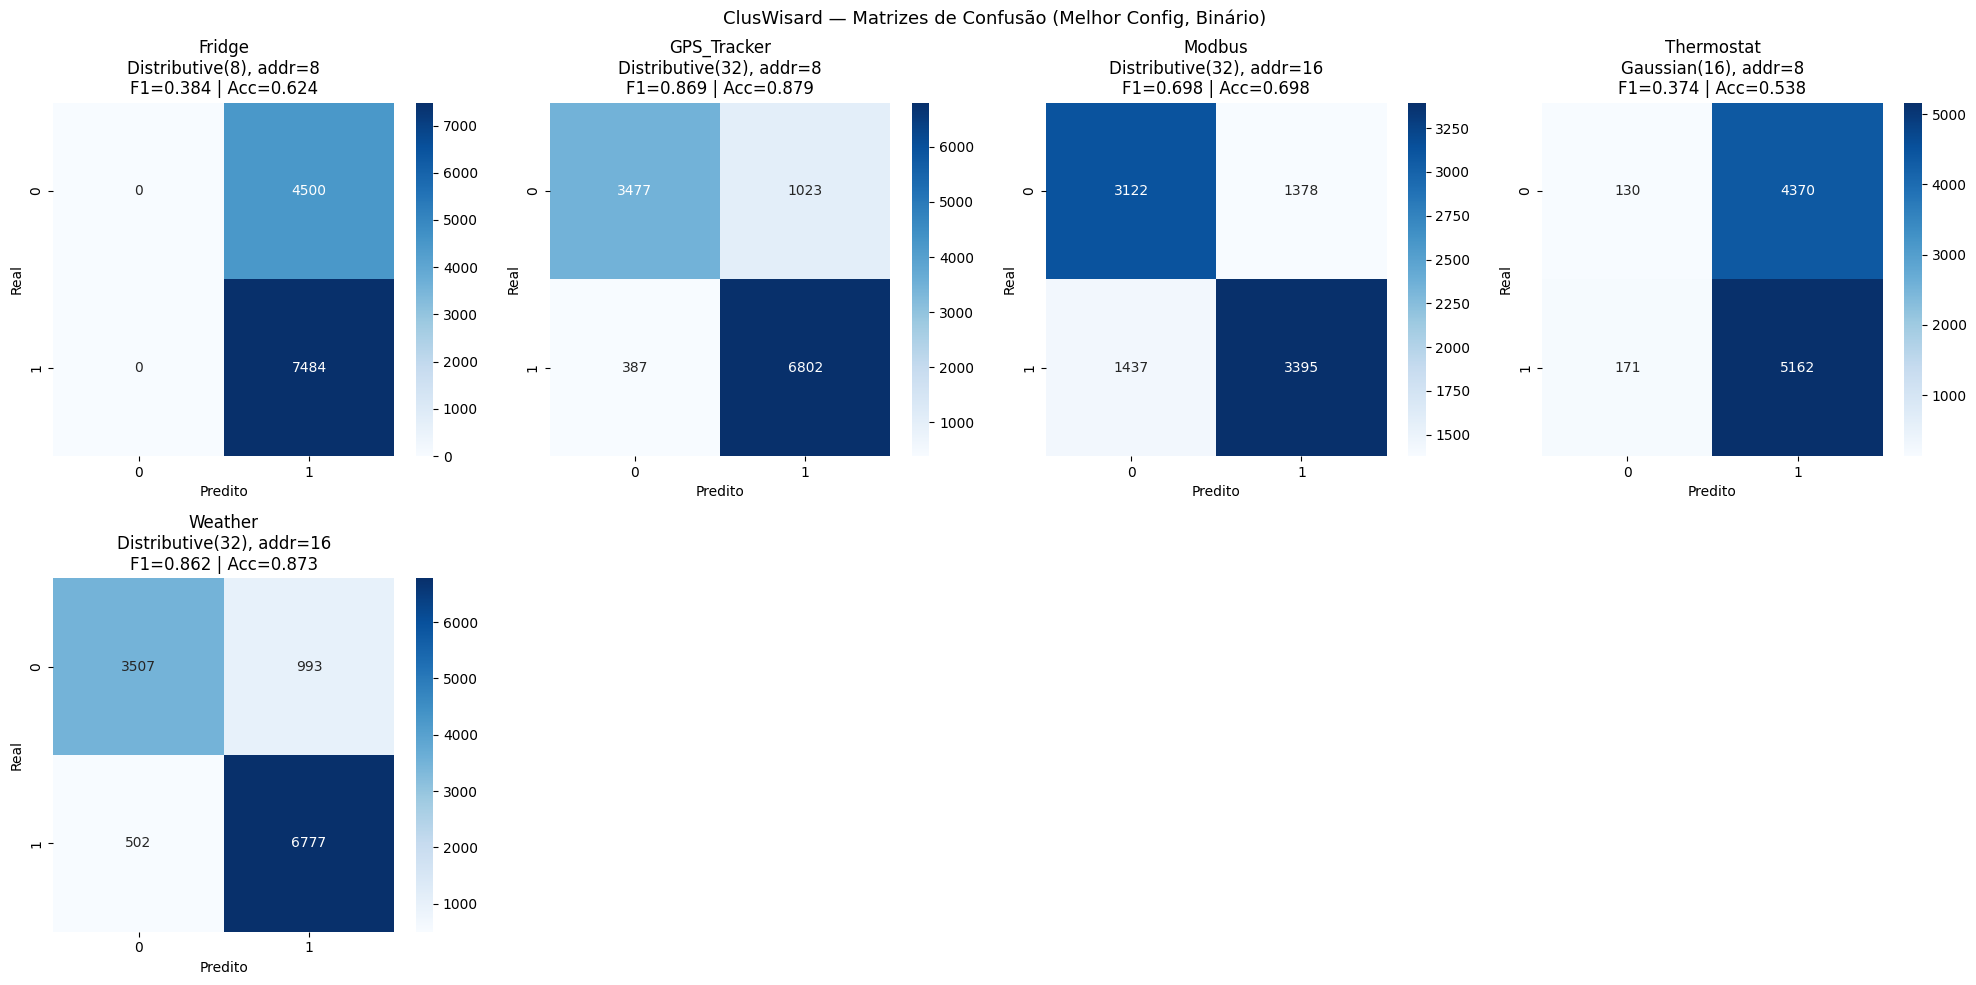

In [38]:
# ── Matrizes de confusão — melhores configs por dataset (binário) ──────────────
best_binary = best[best['task'] == 'binary'].copy()
n_ds = len(best_binary)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(best_binary.iterrows()):
    name = row['dataset']
    # Recuperar resultado completo
    key = f"{name}__binary"
    matching = [
        r for r in all_results.get(key, [])
        if (r.get('thermometer_type') == row['thermometer_type'] and
            r.get('thermometer_size') == row['thermometer_size'] and
            r.get('address_size') == row['address_size'])
    ]
    if not matching:
        axes[i].set_visible(False)
        continue
    r = matching[0]
    cm_arr = np.array(r['confusion_matrix'])
    labels = r['confusion_matrix_labels']
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(f"{name}\n{r['thermometer_type']}({r['thermometer_size']}), "
                      f"addr={r['address_size']}\n"
                      f"F1={r['f1_macro']:.3f} | Acc={r['accuracy']:.3f}")
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predito')

for j in range(n_ds, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ClusWisard — Matrizes de Confusão (Melhor Config, Binário)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'confusion_matrices_binary.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ── Tabela de tempo de treino e latência de inferência ────────────────────────
timing_cols = ['dataset', 'task', 'thermometer_type', 'thermometer_size',
               'address_size', 'train_time_s', 'infer_latency_us', 'memory_kb']

print("=" * 80)
print("Melhor config por Dataset/Task — Desempenho computacional")
print("=" * 80)
print(best[timing_cols].to_string(index=False))

Melhor config por Dataset/Task — Desempenho computacional
    dataset       task thermometer_type  thermometer_size  address_size  train_time_s  infer_latency_us  memory_kb
     Fridge     binary     Distributive                 8             8        0.0792           19.8495     2.6900
     Fridge multiclass         Gaussian                32            16        0.1994          594.2650    53.7200
GPS_Tracker     binary     Distributive                32             8        0.9873          557.9548    72.0500
GPS_Tracker multiclass     Distributive                32            16        0.6331         1744.5013   127.9900
     Modbus     binary     Distributive                32            16        1.6508          294.8614   458.8800
     Modbus multiclass     Distributive                32            16        2.9461         1629.7805   772.4500
 Thermostat     binary         Gaussian                16             8        0.1086           74.1954    10.9400
 Thermostat multiclass

## 10. Análise Multi-classe

In [40]:
df_multi = df_all[df_all['task'] == 'multiclass'].copy()

if df_multi.empty:
    print("Nenhum resultado multi-classe disponível ainda.")
else:
    best_multi = (
        df_multi[display_cols]
        .sort_values('f1_macro', ascending=False)
        .groupby('dataset')
        .first()
        .reset_index()
    )
    print("=" * 80)
    print("Melhor configuração por Dataset — Tarefa Multi-classe")
    print("=" * 80)
    print(best_multi.to_string(index=False))

Melhor configuração por Dataset — Tarefa Multi-classe
    dataset       task thermometer_type  thermometer_size  address_size  accuracy  f1_macro  f1_weighted auc_roc  train_time_s  infer_latency_us  memory_kb
     Fridge multiclass         Gaussian                32            16    0.3755    0.0780       0.2050    None        0.1994          594.2650    53.7200
GPS_Tracker multiclass     Distributive                32            16    0.5808    0.3772       0.5678    None        0.6331         1744.5013   127.9900
     Modbus multiclass     Distributive                32            16    0.6773    0.5500       0.6611    None        2.9461         1629.7805   772.4500
 Thermostat multiclass     Distributive                 8             8    0.4577    0.0897       0.2875    None        0.0498          175.9513    14.2100
    Weather multiclass     Distributive                32            16    0.8303    0.8002       0.8266    None        2.0623         1867.4514   480.4200


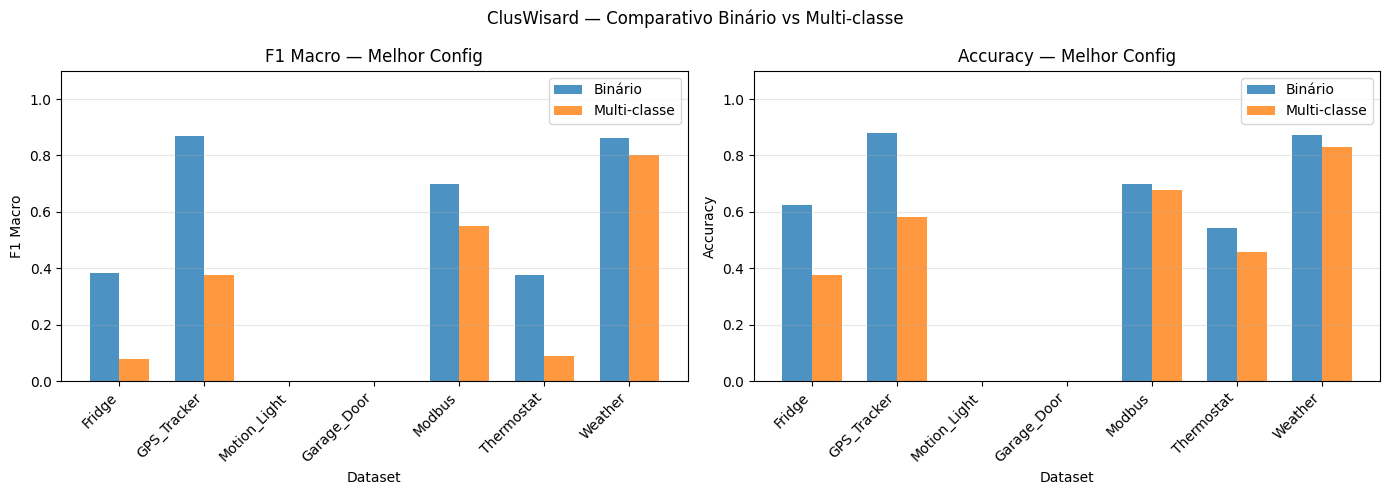

In [41]:
# ── Comparativo binário vs multi-classe ────────────────────────────────────────
if not df_multi.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, ['f1_macro', 'accuracy']):
        comparison = pd.DataFrame({
            'Dataset': list(DATASETS.keys()),
        })
        for task in TASKS:
            vals = []
            for name in DATASETS.keys():
                key = f"{name}__{task}"
                sub = df_all[
                    (df_all['dataset'] == name) &
                    (df_all['task'] == task)
                ]
                vals.append(sub[metric].max() if not sub.empty else 0.0)
            comparison[task] = vals

        x = np.arange(len(DATASETS))
        width = 0.35
        bars1 = ax.bar(x - width/2, comparison['binary'], width, label='Binário', alpha=0.8)
        bars2 = ax.bar(x + width/2, comparison['multiclass'], width, label='Multi-classe', alpha=0.8)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_title(f'{metric.replace("_", " ").title()} — Melhor Config')
        ax.set_xticks(x)
        ax.set_xticklabels(list(DATASETS.keys()), rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('ClusWisard — Comparativo Binário vs Multi-classe')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'binary_vs_multiclass.png', dpi=150)
    plt.show()

## 11. Salvar Resultados Consolidados

In [42]:
# Salvar todos os resultados em um único arquivo
all_path = RESULTS_PATH / 'all_results.json'
with open(all_path, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, default=str)
print(f"Resultados consolidados salvos em: {all_path}")

# Salvar CSV para análise fácil
csv_path = RESULTS_PATH / 'all_results.csv'
df_all[display_cols].to_csv(csv_path, index=False)
print(f"CSV salvo em: {csv_path}")

# Resumo final
print("\n=" * 40)
print("RESUMO FINAL")
print("=" * 40)
print(f"Total de experimentos: {len(df_all)}")
print(f"Datasets: {list(DATASETS.keys())}")
print(f"Tarefas: {TASKS}")
print(f"Resultados em: {RESULTS_PATH}")

if not df_all.empty:
    print(f"\nMelhor F1 Macro global:")
    best_global = df_all.loc[df_all['f1_macro'].idxmax()]
    print(f"  Dataset: {best_global['dataset']}")
    print(f"  Task: {best_global['task']}")
    print(f"  Termômetro: {best_global['thermometer_type']}({best_global['thermometer_size']})")
    print(f"  Address Size: {best_global['address_size']}")
    print(f"  F1 Macro: {best_global['f1_macro']:.4f}")
    print(f"  Acurácia: {best_global['accuracy']:.4f}")
    print(f"  AUC-ROC: {best_global.get('auc_roc')}")

Resultados consolidados salvos em: results\cluswisard\all_results.json
CSV salvo em: results\cluswisard\all_results.csv

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
RESUMO FINAL
Total de experimentos: 172
Datasets: ['Fridge', 'GPS_Tracker', 'Motion_Light', 'Garage_Door', 'Modbus', 'Thermostat', 'Weather']
Tarefas: ['binary', 'multiclass']
Resultados em: results\cluswisard

Melhor F1 Macro global:
  Dataset: GPS_Tracker
  Task: binary
  Termômetro: Distributive(32)
  Address Size: 4
  F1 Macro: 0.8688
  Acurácia: 0.8794
  AUC-ROC: None


## Referências

- **WiSARD**: Aleksander, I. et al. (1984). A weightless neural network. *Electronics Letters*.
- **ClusWisard**: De Gregorio, M., & Giordano, M. (2013). ClusWiSARD: A weightless neural network for pattern recognition. *IEEE ICDMW*.
- **TON_IoT**: Moustafa, N. et al. (2021). TON_IoT: The Role of Heterogeneity and the Need for Standardisation of Features and Attack Types in IoT Network Intrusion Datasets. *IEEE Internet of Things Journal*.
- **wisardpkg**: https://github.com/muanlartins/wisardpkg (fork com termômetros ajustados)
- **PLANO.md**: Roteiro do trabalho, notebooks/toniot/